# 09 — Guarded pre/post event analysis
**Purpose:** compare the 12 months before a documented event with historical same-month conditions and create optical/SAR pre/post screening products.  
**Inputs:** verified event citation and dates, notebook 08 feature table, GLIMS/context ROIs, and Earth Engine imagery.  
**Outputs:** event metadata, historical-percentile table/chart, pre/post sensor metrics, and interactive change-screening maps.  
**Runtime:** typically 5–15 minutes; map tiles render on demand.  
**Dependencies:** completed notebooks 05, 06, and 08; authenticated Earth Engine; packages in `requirements.txt`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/langtang-glacier-ai'
%pip -q install -r requirements.txt


Mounted at /content/drive
/content/drive/MyDrive/langtang-glacier-ai
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 101.4 MB/s eta 0:00:00


## Required verified event information
Replace every `None` below using one authoritative source. Earth Engine end dates are exclusive. The pre window must end on or before the event date; the post window must start on or after it. Use comparable seasonal windows and inspect scene availability. The notebook intentionally stops if any value or citation is missing.

In [4]:
EVENT_DATE = "2026-08-26"

EVENT_SOURCE = (
    "https://www.esa.int/Applications/Observing_the_Earth/Copernicus/"
    "Sentinel-2/Nepal_flash_flood_imaged_by_satellites"
)

# Equal seven-day optical windows; end dates are exclusive.
PRE_START = "2026-08-19"
PRE_END = "2026-08-26"

POST_START = "2026-08-27"
POST_END = "2026-09-03"


In [5]:
import json
import os
import sys
from pathlib import Path
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import ee
import geemap
import pandas as pd
from src.config import SETTINGS
from src.event_analysis import (
    EventWindows, build_pre_event_percentiles,
    make_event_sentinel2_products, nearest_sentinel1_event_windows,
    optical_candidate_change_polygons, sentinel1_event_metrics,
    sentinel2_event_metrics,
)
from src.gee_utils import build_rois, initialize_earth_engine
from src.sar_features import choose_sentinel1_track, sentinel1_difference
from src.trend_analysis import load_integrated_features
from src.utils import ensure_output_directories
from src.visualization import (
    INDEX_DELTA_VIS, NDSI_VIS, NDVI_VIS, RGB_VIS, S1_DELTA_VIS,
    S1_VH_VIS, S1_VV_VIS, make_study_area_map,
    plot_pre_event_percentiles,
)
ensure_output_directories()

required = {
    'EVENT_DATE': EVENT_DATE, 'EVENT_SOURCE': EVENT_SOURCE,
    'PRE_START': PRE_START, 'PRE_END': PRE_END,
    'POST_START': POST_START, 'POST_END': POST_END,
}
missing = [name for name, value in required.items() if not value]
if missing:
    raise ValueError(
        'Enter verified event metadata in the parameter cell first: ' +
        ', '.join(missing)
    )
windows = EventWindows(
    event_date=EVENT_DATE, event_source=EVENT_SOURCE,
    pre_start=PRE_START, pre_end=PRE_END,
    post_start=POST_START, post_end=POST_END,
).validated()
with (SETTINGS.output_tables / 'event_windows.json').open('w') as file:
    json.dump(windows.metadata(), file, indent=2)
print(windows.metadata())


{'event_date': '2026-08-26', 'event_source': 'https://www.esa.int/Applications/Observing_the_Earth/Copernicus/Sentinel-2/Nepal_flash_flood_imaged_by_satellites', 'pre_start': '2026-08-19', 'pre_end': '2026-08-26', 'post_start': '2026-08-27', 'post_end': '2026-09-03'}


## Twelve-month historical comparison
Each observation in the 12 complete calendar months before the event is compared only with the same calendar month from years before that 12-month window. The bands are empirical summaries, not confidence intervals. Missing sensor observations remain missing.

,date,feature,observed,historical_count,historical_q05,historical_q25,historical_median,historical_q75,historical_q95
0,2025-08-01,temp_anomaly,0.609156,10,-0.031299,0.144278,0.404041,0.647958,0.851094
1,2025-08-01,precip_month,424.106011,10,313.566513,389.233695,443.626985,509.258973,530.757521
2,2025-08-01,precip_3d_max,63.405191,10,51.099070,67.157352,75.676456,82.275535,120.421873
3,2025-08-01,precip_7d_max,118.513899,10,116.622169,124.766093,150.527981,168.428998,222.113432
4,2025-08-01,PDD,234.573134,10,214.719038,220.161918,228.214590,235.776003,242.073224
...,...,...,...,...,...,...,...,...,...
115,2026-07-01,snow_fraction,0.484757,7,0.343947,0.410214,0.485691,0.628436,0.785217
116,2026-07-01,NDSI,0.354760,7,0.233842,0.301382,0.362386,0.457719,0.606435
117,2026-07-01,VV,-10.228705,9,-10.218108,-10.100607,-9.977360,-9.902433,-9.787026
118,2026-07-01,VH,-19.268328,9,-19.279168,-19.168807,-19.029812,-18.926296,-18.440918


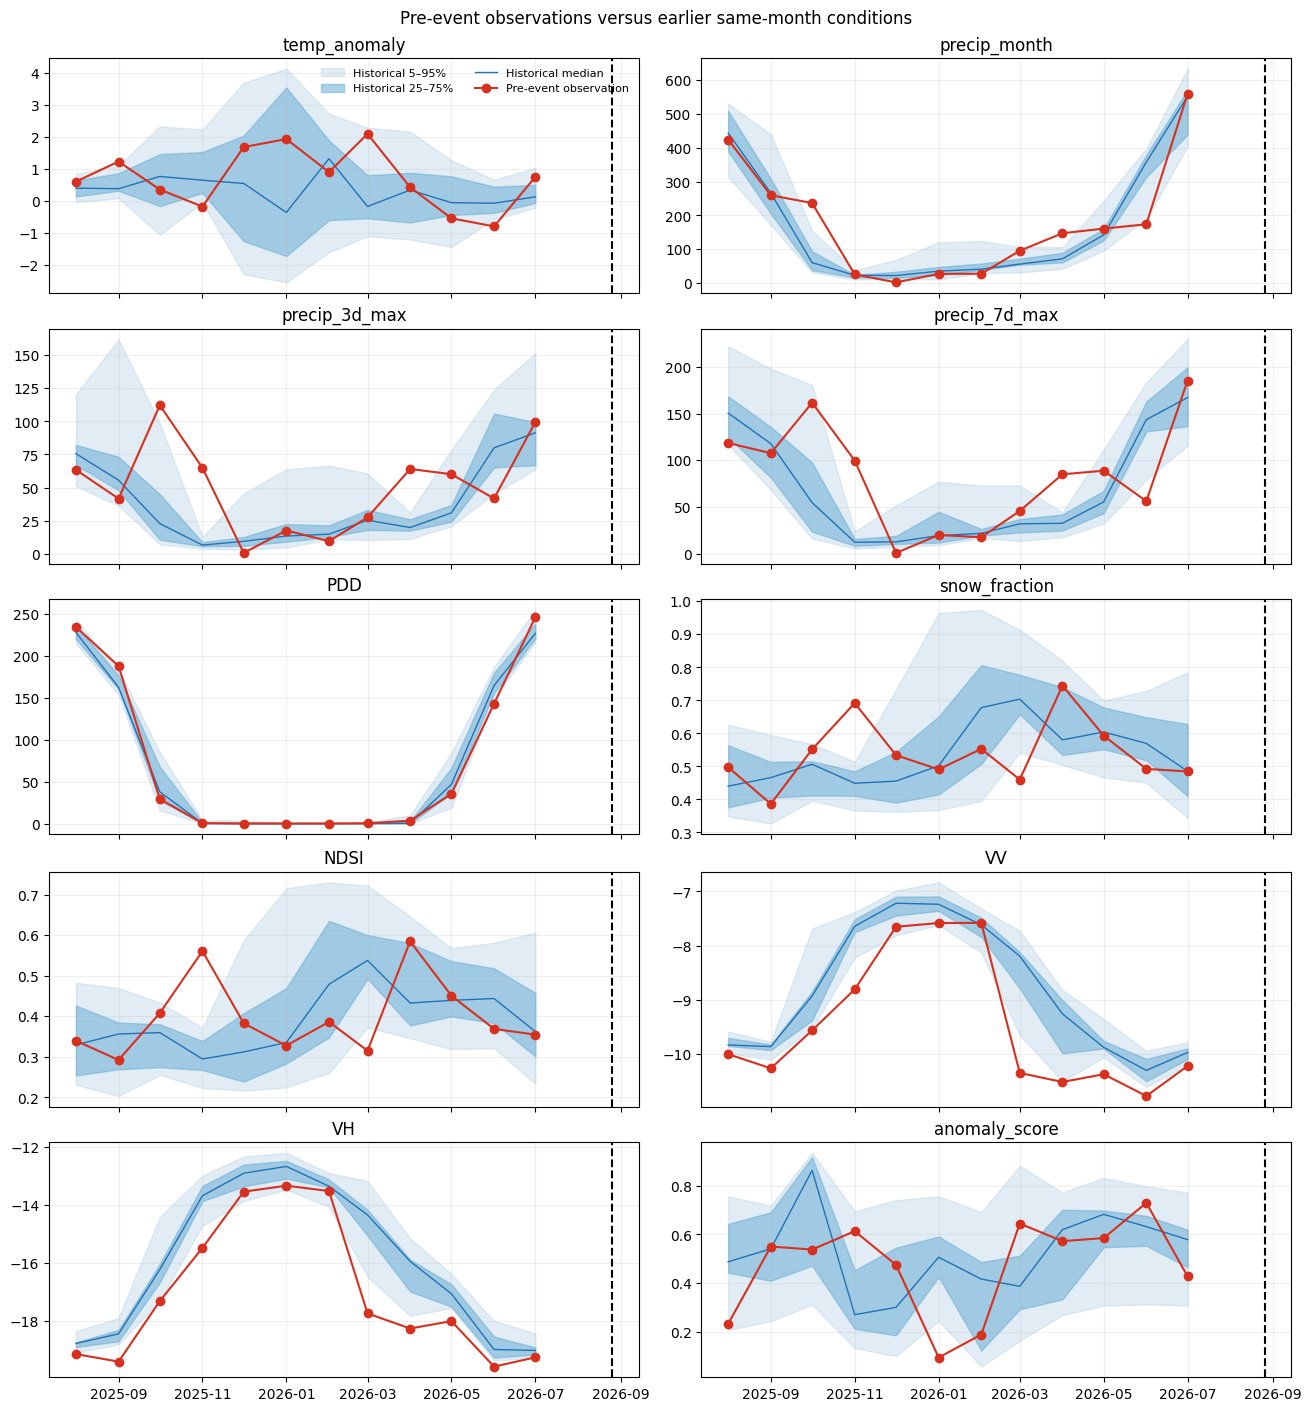

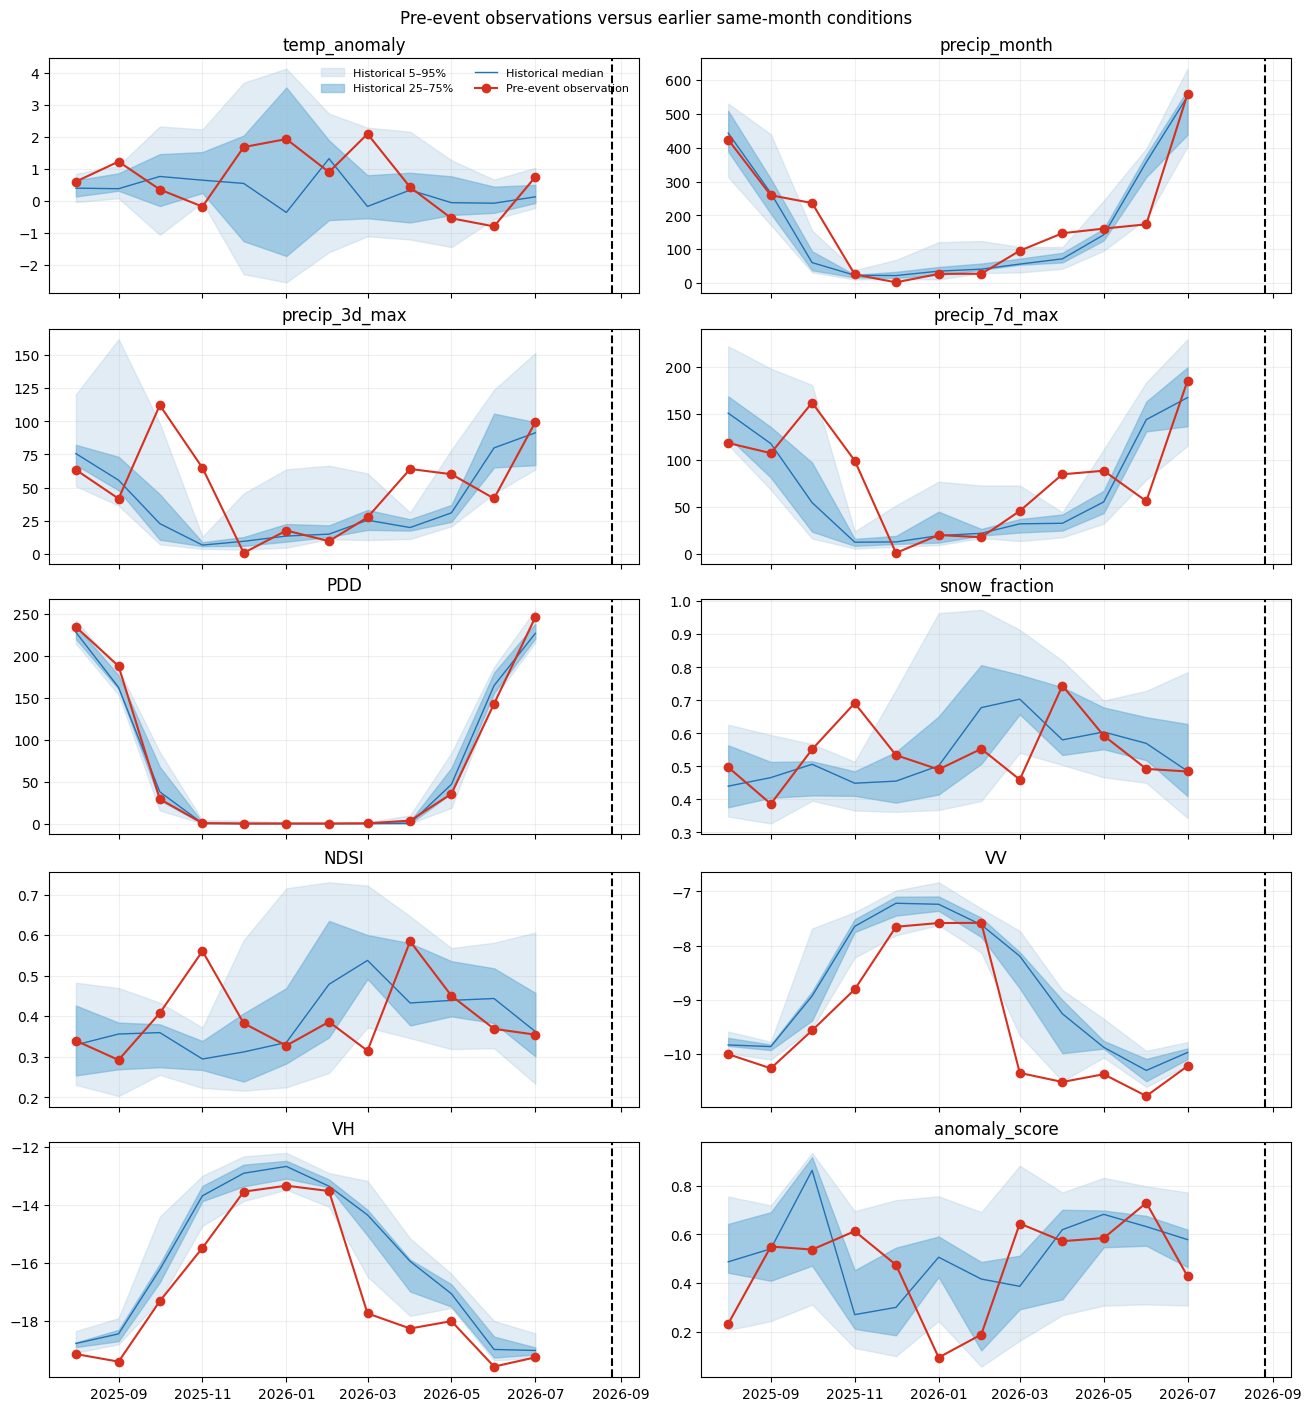

In [6]:
anomaly_path = (
    SETTINGS.output_tables / 'langtang_monthly_features_with_anomaly.csv'
)
feature_path = (
    anomaly_path if anomaly_path.exists()
    else SETTINGS.output_tables / 'langtang_monthly_features.csv'
)
features = load_integrated_features(feature_path)
percentiles = build_pre_event_percentiles(features, windows.event_date)
percentiles.to_csv(
    SETTINGS.output_tables / 'pre_event_historical_percentiles.csv',
    index=False,
)
percentile_figure = plot_pre_event_percentiles(
    percentiles, windows.event_date,
    SETTINGS.output_charts / 'pre_event_historical_percentiles.png',
)
display(percentiles)
display(percentile_figure)


## Earth Engine initialization
Use the Earth Engine-enabled Google Cloud project associated with your account. The source tables above are local; the satellite comparison below requires Earth Engine.

In [8]:
EE_PROJECT = os.environ.get('EE_PROJECT') or input(
    'Earth Engine Cloud project ID: '
).strip()
if not EE_PROJECT:
    raise ValueError('An Earth Engine-enabled Cloud project ID is required.')
try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    initialize_earth_engine(project=EE_PROJECT, authenticate=True)
print('Earth Engine initialized with:', EE_PROJECT)


Earth Engine Cloud project ID: my-youtube-api-keys-453716
Earth Engine initialized with: my-youtube-api-keys-453716


## Sentinel-2 pre/post screening
The composites show RGB, NDSI, NDVI, snow proxy, and post-minus-pre index differences. The wide context is for inspection only and is not an event footprint. Index change can result from cloud/shadow residuals, snow season, illumination, vegetation, water, or debris; it is not an automatically mapped collapse scar.

In [9]:
rois = build_rois()
s2_pre, s2_post, s2_delta = make_event_sentinel2_products(
    rois['downstream_context_roi'], windows
)
s2_metrics = sentinel2_event_metrics(
    s2_pre, s2_post, rois['glacier_roi'], windows
)
s2_metrics.to_csv(
    SETTINGS.output_tables / 'sentinel2_event_metrics.csv', index=False
)
display(s2_metrics)

optical_map = make_study_area_map(rois)
optical_map.addLayer(s2_pre, RGB_VIS, 'Pre-event Sentinel-2 RGB', False)
optical_map.addLayer(s2_post, RGB_VIS, 'Post-event Sentinel-2 RGB', True)
optical_map.addLayer(s2_pre.select('NDSI'), NDSI_VIS, 'Pre NDSI', False)
optical_map.addLayer(s2_post.select('NDSI'), NDSI_VIS, 'Post NDSI', False)
optical_map.addLayer(s2_pre.select('NDVI'), NDVI_VIS, 'Pre NDVI', False)
optical_map.addLayer(s2_post.select('NDVI'), NDVI_VIS, 'Post NDVI', False)
optical_map.addLayer(
    s2_delta.select('delta_NDSI'), INDEX_DELTA_VIS,
    'Delta NDSI (post - pre)', False,
)
optical_map.addLayer(
    s2_delta.select('delta_NDVI'), INDEX_DELTA_VIS,
    'Delta NDVI (post - pre)', False,
)
optical_map.addLayer(
    s2_pre.select('snow').selfMask(), {'palette': ['00D8FF']},
    'Pre snow proxy', False,
)
optical_map.addLayer(
    s2_post.select('snow').selfMask(), {'palette': ['FF00FF']},
    'Post snow proxy', False,
)
optical_map.to_html(
    str(SETTINGS.output_maps / 'sentinel2_event_pre_post.html')
)
optical_map


,date,scene_count,ndsi_mean,snow_area_km2,snow_fraction_valid,valid_area_fraction,mean_valid_observation_count,missing_data_flag,period,expected_observation_count,observation_count,period_completeness,is_complete_period,quality_status,quality_reason,quantitative_change_estimated,ndsi_mean_change_from_pre,snow_area_km2_change_from_pre,snow_fraction_valid_change_from_pre
0,2026-08-19,6,0.246272,1.604005,0.365628,0.840604,1.713181,0,pre,6,1.713181,0.840604,False,INSUFFICIENT,Quantitative change not estimated because opti...,False,NaN,NaN,NaN
1,2026-08-27,3,0.686506,0.108668,0.905738,0.022989,1.000000,0,post,3,1.000000,0.022989,False,INSUFFICIENT,Quantitative change not estimated because opti...,False,NaN,NaN,NaN


Map(center=[28.251882136909924, 85.54672799144113], controls=(WidgetControl(options=['position', 'transparent_…

## QA-gated candidate optical changes
Candidate polygons are generated only when both pre/post valid-area fractions pass 0.80. They are spectral-change candidates with terrain/connectivity attributes, not validated physical event footprints.

In [10]:
if s2_metrics['quantitative_change_estimated'].all():
    candidate_changes = optical_candidate_change_polygons(
        s2_delta, s2_metrics, rois['glacier_roi'],
        rois['hydrological_catchment_roi'],
    )
    candidate_path = (
        SETTINGS.output_tables / 'candidate_spectral_change_polygons.geojson'
    )
    geemap.ee_export_vector(candidate_changes, str(candidate_path))
    optical_map.addLayer(
        candidate_changes, {'color': 'FF00FF'},
        'Candidate spectral-change polygons (unvalidated)', False,
    )
    optical_map.to_html(
        str(SETTINGS.output_maps / 'sentinel2_event_pre_post.html')
    )
    print('Saved:', candidate_path)
else:
    print(s2_metrics['quality_reason'].iloc[0])


Quantitative change not estimated because optical coverage is insufficient.


## Sentinel-1 pre/post screening
Sentinel-1 does not necessarily observe the site inside the optical windows. The code therefore finds the nearest acquisition strictly before and after the event within 60 days, using the same orbit direction and relative orbit, and records the actual dates. Differences are post minus pre in dB. They are sensitive to snow state, moisture, roughness, acquisition timing, layover, and radar shadow; they are not displacement and this is not InSAR.

In [11]:
track = choose_sentinel1_track(rois['glacier_roi'])
s1_windows = nearest_sentinel1_event_windows(
    rois['glacier_roi'], windows.event_date, track, required=False
)
print('Sentinel-1 availability:', s1_windows)
metadata = windows.metadata() | {
    f'sentinel1_{key}': value for key, value in s1_windows.items()
}
with (SETTINGS.output_tables / 'event_windows.json').open('w') as file:
    json.dump(metadata, file, indent=2)

if not s1_windows['available']:
    print(
        'Sentinel-1 comparison skipped without failing the notebook. '
        'Rerun this cell after the post-event archive is updated.'
    )
else:
    s1_pre, s1_post, s1_delta = sentinel1_difference(
        rois['downstream_context_roi'],
        s1_windows['pre_start'], s1_windows['pre_end'],
        s1_windows['post_start'], s1_windows['post_end'], track,
    )
    s1_metrics = sentinel1_event_metrics(
        s1_pre, s1_post, rois['glacier_roi'],
        s1_windows['pre_start'], s1_windows['post_start'],
    )
    s1_metrics.to_csv(
        SETTINGS.output_tables / 'sentinel1_event_metrics.csv', index=False
    )
    display(s1_metrics)
    if s1_metrics[['vv_db', 'vh_db']].isna().any().any():
        print(
            'Warning: a selected SAR acquisition has no valid glacier-ROI '
            'pixels; inspect the quality fields and map.'
        )

    sar_map = make_study_area_map(rois)
    sar_map.addLayer(s1_pre.select('VV'), S1_VV_VIS, 'Pre VV', False)
    sar_map.addLayer(s1_post.select('VV'), S1_VV_VIS, 'Post VV', True)
    sar_map.addLayer(s1_pre.select('VH'), S1_VH_VIS, 'Pre VH', False)
    sar_map.addLayer(s1_post.select('VH'), S1_VH_VIS, 'Post VH', False)
    sar_map.addLayer(
        s1_delta.select('delta_VV'), S1_DELTA_VIS,
        'Delta VV (post - pre)', False,
    )
    sar_map.addLayer(
        s1_delta.select('delta_VH'), S1_DELTA_VIS,
        'Delta VH (post - pre)', False,
    )
    sar_map.to_html(
        str(SETTINGS.output_maps / 'sentinel1_event_pre_post.html')
    )
    display(sar_map)


Sentinel-1 availability: {'available': True, 'pre_start': '2026-08-16', 'pre_end': '2026-08-17', 'post_start': '2026-08-28', 'post_end': '2026-08-29', 'pre_days_before_event': 10, 'post_days_after_event': 2, 'pre_valid_area_fraction': 0.9561520610954632, 'post_valid_area_fraction': 0.9561520610954632, 'orbit_pass': 'ASCENDING', 'relative_orbit': 85, 'search_days': 60}


,date,vv_db,vv_std_db,vh_db,vh_std_db,angle_deg,mean_valid_observation_count,valid_area_fraction,scene_count,missing_data_flag,...,period,observation_count,expected_observation_count,period_completeness,is_complete_period,quality_status,quality_reason,quantitative_change_estimated,vv_db_change_from_pre,vh_db_change_from_pre
0,2026-08-16,-10.217750,8.589935,-19.408571,7.656171,40.413604,1,0.956152,1,0,...,pre,1,<NA>,0.956152,True,GOOD,Both pre/post observations pass the coverage t...,True,0.000000,0.000000
1,2026-08-28,-10.242274,8.622288,-19.259075,7.481271,40.413136,1,0.956152,1,0,...,post,1,<NA>,0.956152,True,GOOD,Both pre/post observations pass the coverage t...,True,-0.024524,0.149496


Map(center=[28.251882136909924, 85.54672799144113], controls=(WidgetControl(options=['position', 'transparent_…

## Interpretation checkpoint
Confirm the citation, date chronology, season matching, scene counts, valid-area fractions, observation counts, orbit selection, and visible cloud/terrain artifacts before comparing periods. The GLIMS outline and wide context are not a 2026 event boundary. These products screen for spectral or backscatter change; they do not establish cause, predict collapse, measure displacement, delineate an avalanche automatically, or estimate volume.